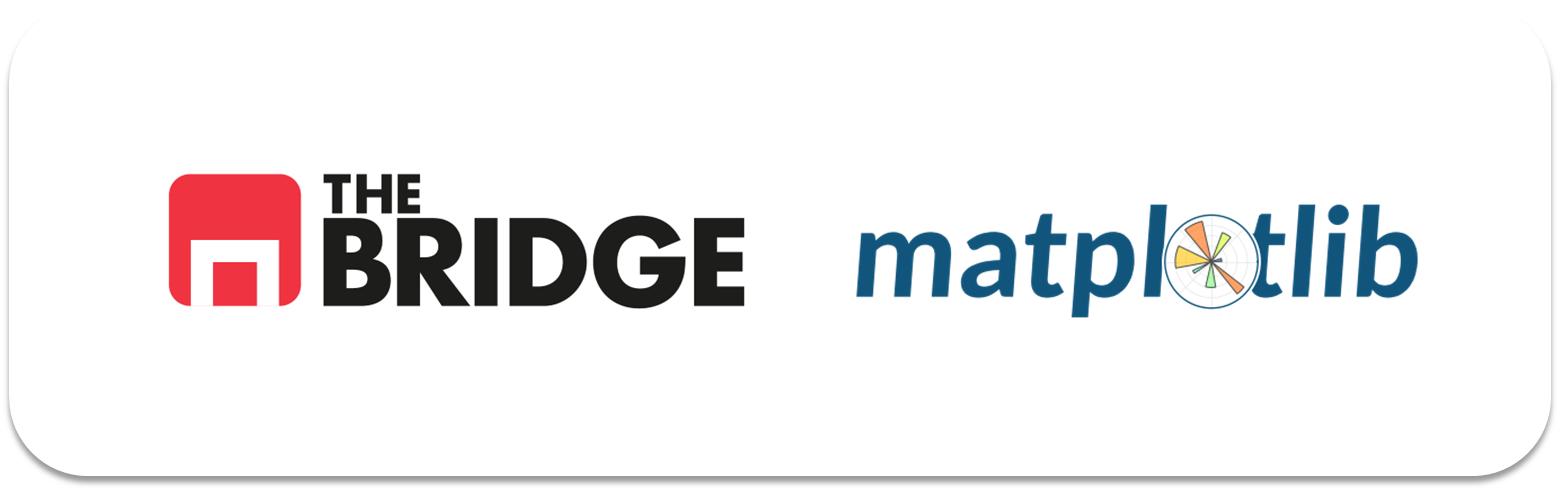

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
# Carga
df_cities = pd.read_csv("./data/california_cities.csv")

# Exploración rápida
print(df_cities.head())
print(df_cities.describe())

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

In [3]:
# Limpieza de nulos
df_cities.dropna(inplace=True)

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

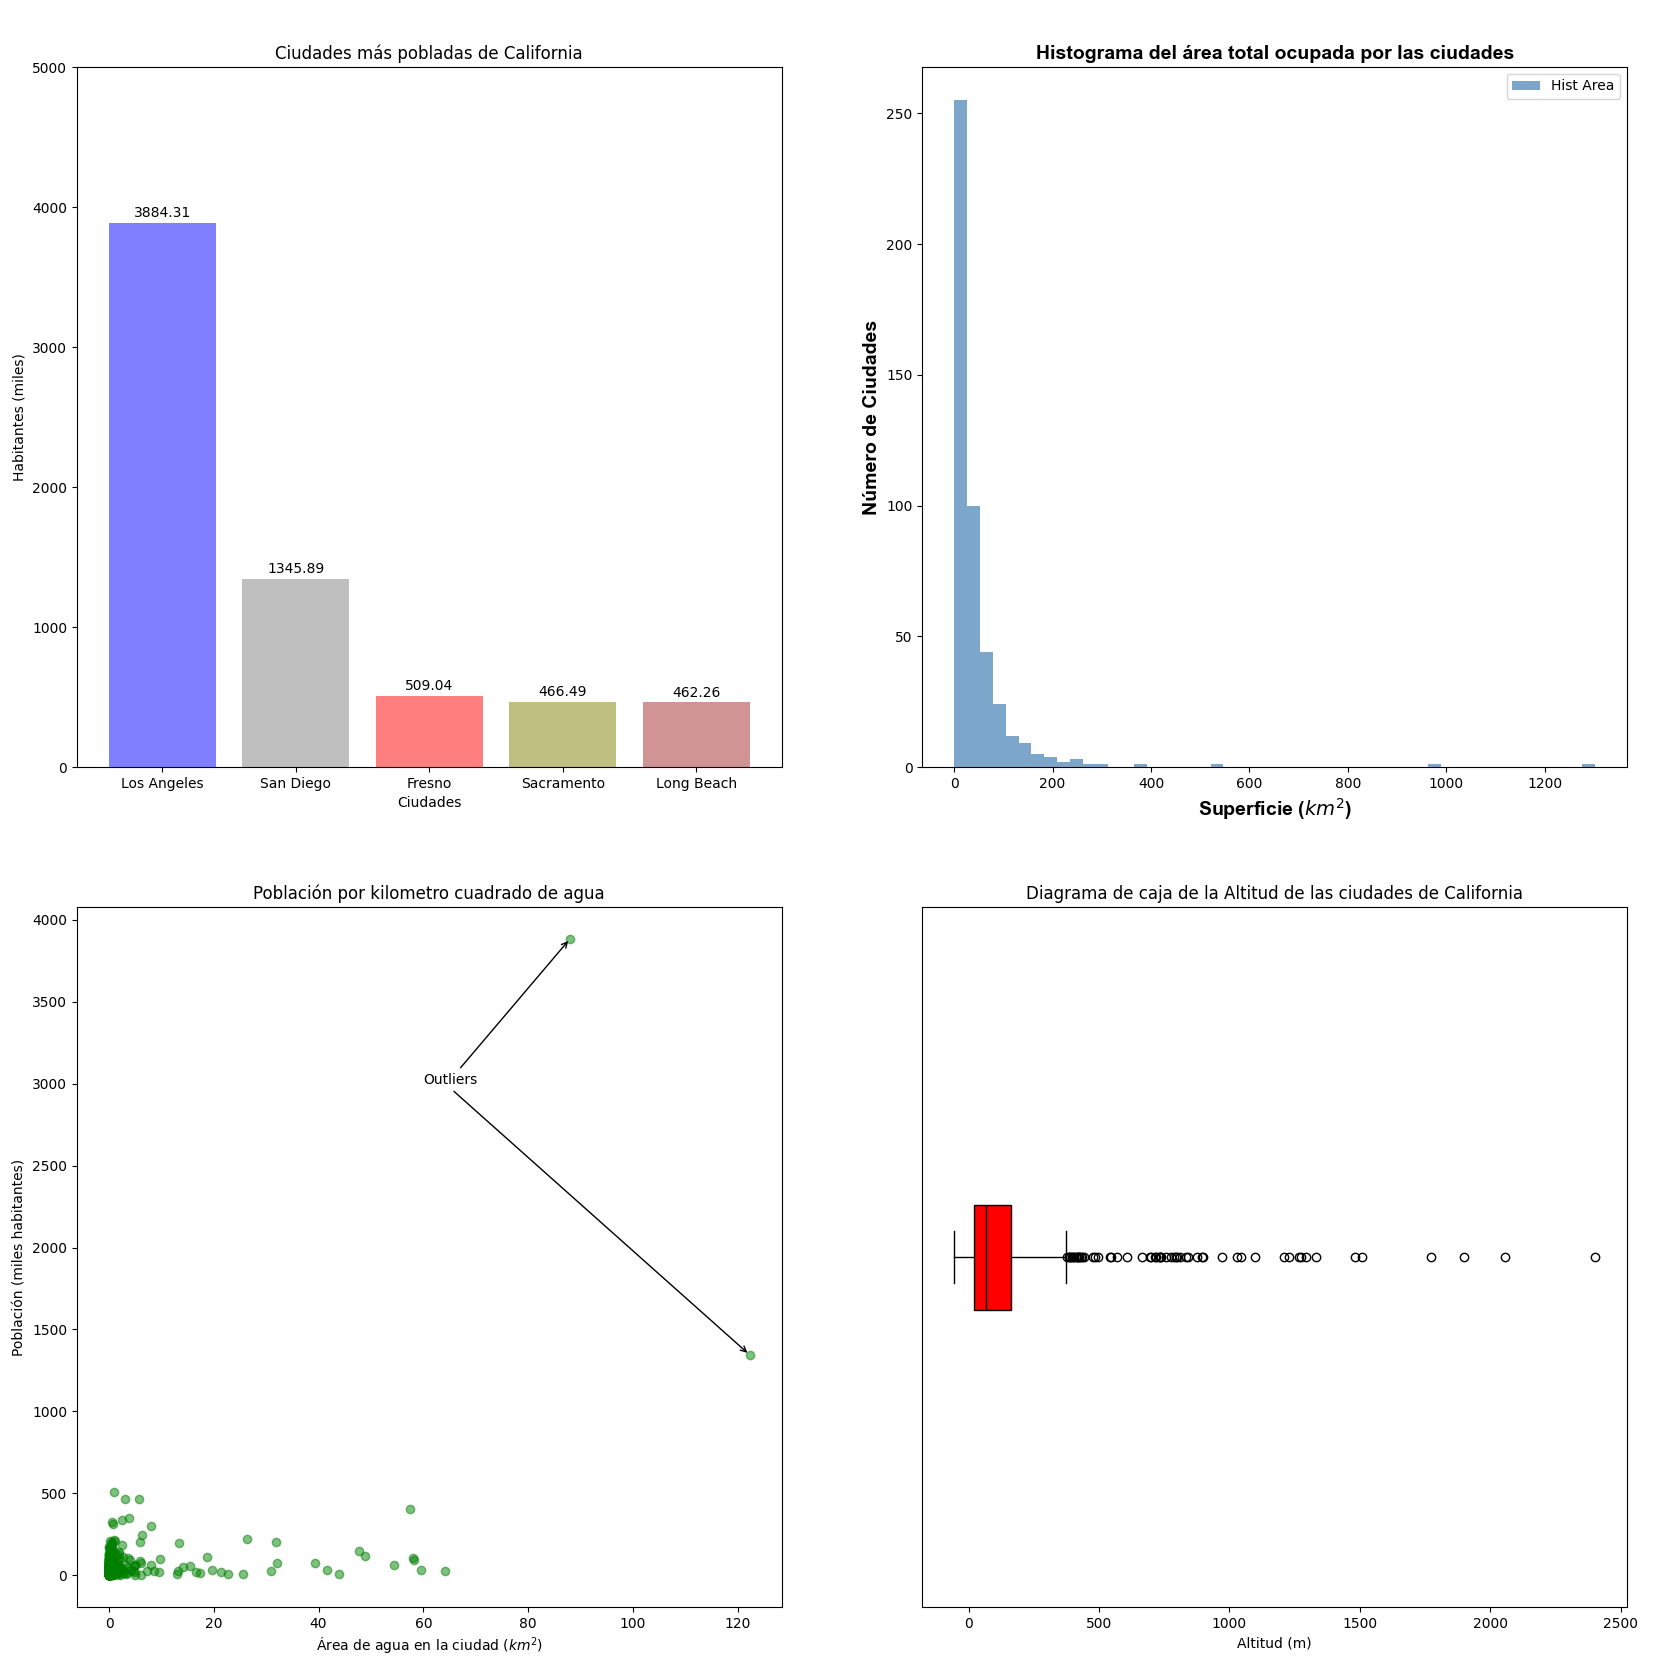

In [5]:
# Para que el código sea limpio, primero voy a definir los datos para las gráficas específicas (como las ciudades más pobladas) y luego usaré plt.subplots(2, 2) para montarlo todo.

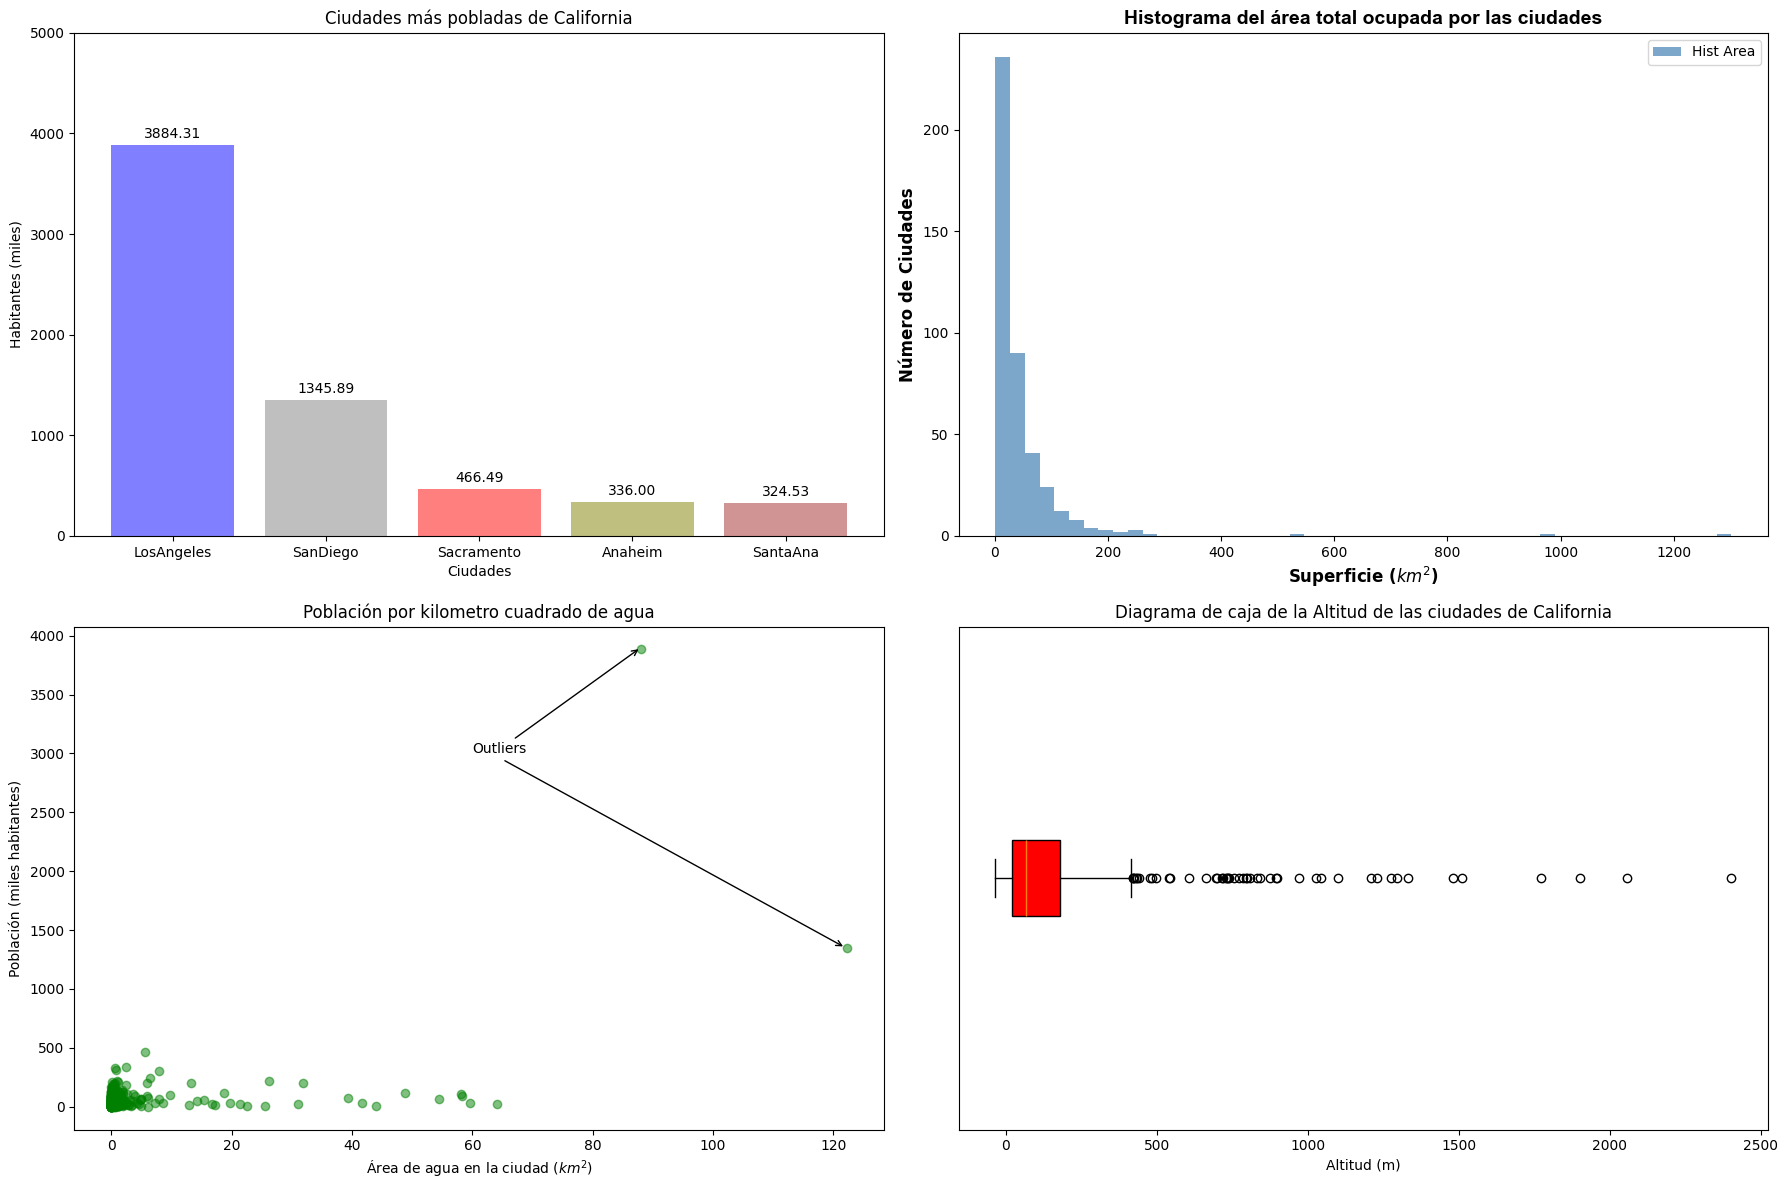

In [4]:
# Preparación de datos específicos para el Bar Chart
# Dividimos por 1000 para que la escala sea "miles de habitantes"
df_top_pop = df_cities.sort_values("population_total", ascending=False).head(5).copy()
df_top_pop["pop_miles"] = df_top_pop["population_total"] / 1000

# CONFIGURACIÓN DE LA FIGURA COMPLETA
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# --- 1. Gráfico de Barras (Top Ciudades) ---
colores = ['blue', 'gray', 'red', 'olive', 'brown']
bars = ax[0, 0].bar(df_top_pop["city"], df_top_pop["pop_miles"], color=colores, alpha=0.5)
ax[0, 0].set_title("Ciudades más pobladas de California")
ax[0, 0].set_ylabel("Habitantes (miles)")
ax[0, 0].set_xlabel("Ciudades")
ax[0, 0].set_ylim(0, 5000)

# Añadir etiquetas de datos
ax[0, 0].bar_label(bars, fmt='%.2f', padding=3)


# --- 2. Histograma del Área Total ---
fuente_titulo = {'family': 'Arial', 'size': 14, 'weight': 'bold'}
ax[0, 1].hist(df_cities["area_total_km2"], bins=50, color="steelblue", alpha=0.7, label="Hist Area")
ax[0, 1].set_title("Histograma del área total ocupada por las ciudades", fontdict=fuente_titulo)
ax[0, 1].set_xlabel("Superficie ($km^2$)", fontweight='bold', fontsize=12)
ax[0, 1].set_ylabel("Número de Ciudades", fontweight='bold', fontsize=12)
ax[0, 1].legend()


# --- 3. Scatter Plot (Agua vs Población) ---
# Usamos población en miles para el eje Y
pop_miles_total = df_cities["population_total"] / 1000
ax[1, 0].scatter(df_cities["area_water_km2"], pop_miles_total, color="green", alpha=0.5)
ax[1, 0].set_title("Población por kilometro cuadrado de agua")
ax[1, 0].set_xlabel("Área de agua en la ciudad ($km^2$)")
ax[1, 0].set_ylabel("Población (miles habitantes)")

# Anotación de Outliers (flechas dobles)
# Basándonos en la imagen, apuntan a los dos puntos más lejanos
ax[1, 0].annotate('Outliers', xy=(88, 3900), xytext=(60, 3000),
                 arrowprops=dict(arrowstyle='->'))
ax[1, 0].annotate('', xy=(122, 1350), xytext=(65, 2950),
                 arrowprops=dict(arrowstyle='->'))


# --- 4. Boxplot de Altitud ---
ax[1, 1].boxplot(df_cities["elevation_m"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="red"))
ax[1, 1].set_title("Diagrama de caja de la Altitud de las ciudades de California")
ax[1, 1].set_xlabel("Altitud (m)")
# Quitamos los números del eje Y ya que es un boxplot horizontal de una sola variable
ax[1, 1].get_yaxis().set_visible(False)

plt.tight_layout()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [6]:
# Guardar la figura
fig.savefig("ejercicio_final_california.png")
plt.show()